In [1]:
import pandas as pd
import os
import random
import warnings
warnings.filterwarnings("ignore")
base_path = "C:/Users/harou/Desktop/QoSBuddy_DSIP_VizBiz_CESNET3_Dataset/ip_addresses_full/agg_10_minutes"

folders = ["2", "3", "4", "5", "6", "7"]

all_files = []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".csv")]
    
    sampled_files = random.sample(files, min(30, len(files)))  
    all_files.extend(sampled_files)

print(f"Total files selected: {len(all_files)}")

Total files selected: 180


In [2]:
dfs = []

for file in all_files:
    df = pd.read_csv(file)
    
    # Add identifier (important later)
    df["source_file"] = os.path.basename(file)
    
    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)

print(merged_df.shape)

(1289355, 14)


In [3]:
time_path = "C:/Users/harou/Desktop/QoSBuddy_DSIP_VizBiz_CESNET3_Dataset/times/times_10_minutes.csv"
time_df = pd.read_csv(time_path)

In [4]:
merged_df = merged_df.merge(time_df, on="id_time", how="left")

In [5]:
merged_df.rename(columns={"time": "timestamp"}, inplace=True)

In [6]:
merged_df.drop(columns=["id_time"],inplace=True)

In [7]:
merged_df = merged_df.dropna()

merged_df = merged_df.sort_values(by="timestamp")

merged_df = merged_df.reset_index(drop=True)

merged_df.head()

,n_flows,n_packets,n_bytes,n_dest_asn,n_dest_ports,n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,source_file,timestamp
0,6,6,318,5.0,6.0,6.0,0.83,0.63,0.50,0.38,0.00,123.83,323888.csv,2023-10-09 02:03:49+02:00
1,9,10,420,7.0,8.0,8.0,0.90,0.88,0.30,0.29,0.01,206.67,598414.csv,2023-10-09 02:03:49+02:00
2,24,25,1813,5.0,5.0,17.0,0.12,0.07,0.44,0.56,0.00,97.50,666378.csv,2023-10-09 02:03:49+02:00
3,31,44,1632,9.0,8.0,29.0,0.23,0.25,0.39,0.38,1.93,193.65,616564.csv,2023-10-09 02:03:49+02:00
4,3,4,164,3.0,3.0,3.0,1.00,1.00,0.25,0.24,0.00,207.00,95221.csv,2023-10-09 02:03:49+02:00


In [8]:
merged_df.head(10).to_csv("output.csv", index=False)

In [9]:
features = [
    "n_bytes",
    "n_packets",
    "n_flows",
    "tcp_udp_ratio_packets",
    "dir_ratio_packets"
]

X = merged_df[features]

In [10]:
X.head()

,n_bytes,n_packets,n_flows,tcp_udp_ratio_packets,dir_ratio_packets
0,318,6,6,0.83,0.50
1,420,10,9,0.90,0.30
2,1813,25,24,0.12,0.44
3,1632,44,31,0.23,0.39
4,164,4,3,1.00,0.25


In [11]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

df_train = merged_df.iloc[:split_index].copy()
df_test = merged_df.iloc[split_index:].copy()

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled)

IsolationForest(contamination=0.02, n_jobs=-1, random_state=42)

In [14]:
import joblib
joblib.dump(model, "anomaly_model.pkl")
joblib.dump(scaler, "anomaly_scaler.pkl")

['anomaly_scaler.pkl']

In [15]:
test_scores = model.decision_function(X_test_scaled)
test_labels = model.predict(X_test_scaled)

df_test["anomaly_score"] = test_scores
df_test["anomaly"] = test_labels

In [16]:
print(df_test["anomaly"].value_counts())

anomaly
 1    253927
-1      3944
Name: count, dtype: int64


In [17]:
print(df_test["anomaly_score"].mean())

0.24066065814735174


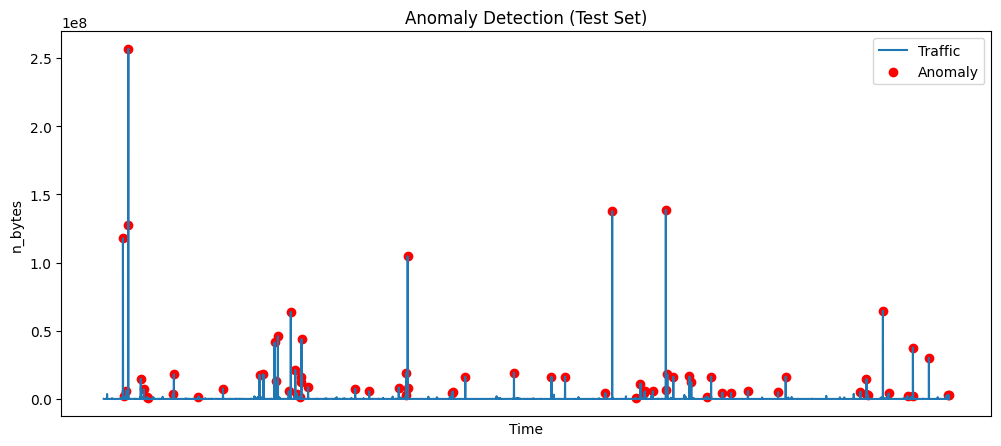

In [18]:
import matplotlib.pyplot as plt
criteria="n_bytes"
sample = df_test[df_test["source_file"] == df_test["source_file"].iloc[0]]

plt.figure(figsize=(12,5))
plt.plot(sample["timestamp"], sample[criteria], label="Traffic")

anomalies = sample[sample["anomaly"] == -1]
plt.scatter(anomalies["timestamp"], anomalies[criteria], color='red', label="Anomaly")
plt.xlabel("Time")
plt.xticks([])
plt.ylabel(criteria)
plt.legend()
plt.title("Anomaly Detection (Test Set)")
plt.show()

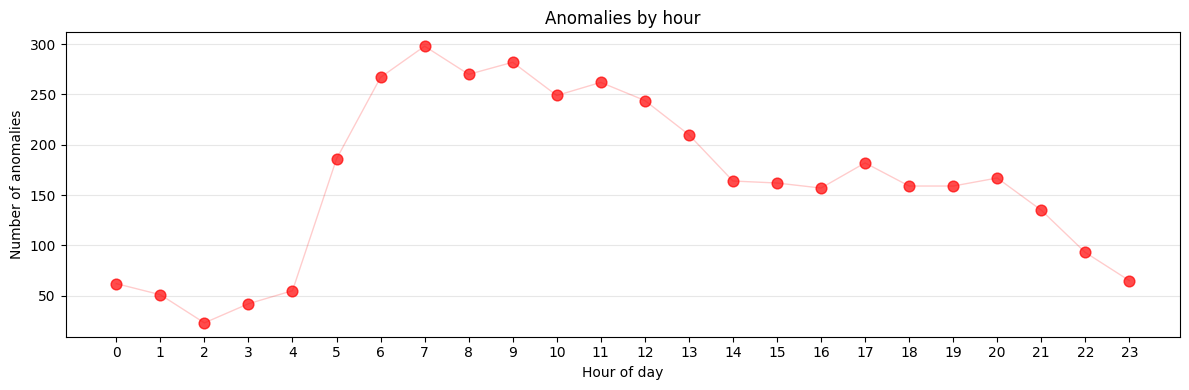

In [19]:
df_test["hour"] = pd.to_datetime(df_test["timestamp"]).dt.hour

anomaly_counts = (
    df_test[df_test["anomaly"] == -1]
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)  
    .reset_index(name="count")
)

plt.figure(figsize=(12, 4))

plt.scatter(
    anomaly_counts["hour"],
    anomaly_counts["count"],
    color="red",
    alpha=0.7,
    s=60,
    zorder=3
)

plt.plot(
    anomaly_counts["hour"],
    anomaly_counts["count"],
    color="red",
    alpha=0.2,
    linewidth=1
)

plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Number of anomalies")
plt.title("Anomalies by hour")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
df_test.groupby("anomaly")[features].mean()

,n_bytes,n_packets,n_flows,tcp_udp_ratio_packets,dir_ratio_packets
anomaly,,,,,
-1,2.150912e+07,21076.127028,42.950304,0.734214,0.306240
1,4.941203e+04,105.869214,6.624384,0.796497,0.469789


In [21]:
anomaly_sample = df_test[df_test["anomaly"] == -1].iloc[501][features]

In [22]:
anomaly_sample

n_bytes                  11941287
n_packets                    8223
n_flows                        33
tcp_udp_ratio_packets         1.0
dir_ratio_packets            0.01
Name: 1059843, dtype: object

In [23]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [24]:
import shap
import pandas as pd

def explain_single_anomaly(row, model, scaler, feature_names):  
    
    row_scaled = scaler.transform([row])
    row_df = pd.DataFrame(row_scaled, columns=feature_names)

    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(row_df)

    
    contributions = pd.DataFrame({
        'feature': feature_names,
        'actual_value': row,
        'shap_value': shap_values[0]
    })

    contributions['abs_shap'] = contributions['shap_value'].abs()
    contributions = contributions.sort_values('abs_shap', ascending=False)
    
    return contributions

In [25]:
def plot_contributions(contributions, top_n=10):
    
    df = contributions.head(top_n).copy()
    
    colors = df['shap_value'].apply(lambda x: 'blue' if x > 0 else 'red')
    
    plt.figure(figsize=(8, 5))
    
    plt.barh(
        df['feature'],
        df['shap_value'],
        color=colors
    )
    
    plt.xlabel("SHAP Value (Impact on Anomaly)")
    plt.title("Feature Contributions to Anomaly")
    plt.gca().invert_yaxis()
    
    plt.show()

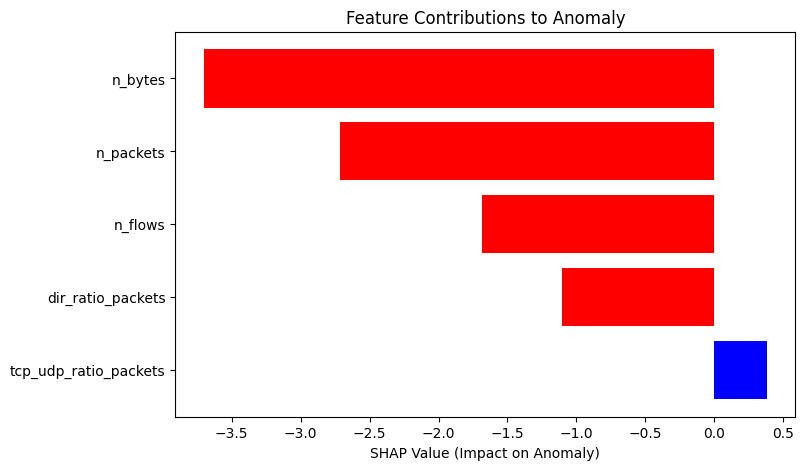

In [26]:
contributions=explain_single_anomaly(anomaly_sample,model,scaler,X_test.columns.tolist())
plot_contributions(contributions, len(X_test.columns))

In [27]:
def compute_severity(score, row):
    severity = 0
    
    severity += abs(score) * 10
    
    severity += row["n_bytes"] / 1e7
    
    return severity

In [28]:
def classify_alert(severity):
    if severity > 15:
        return "HIGH"
    elif severity > 8:
        return "MEDIUM"
    else:
        return "LOW"

In [29]:
classify_alert(compute_severity(model.decision_function(pd.DataFrame(anomaly_sample).T),anomaly_sample))

'LOW'

In [30]:
def generate_recommendations(row, mean_bytes):
    findings = []

    if row["n_bytes"] > mean_bytes * 3:
        findings.append("Possible traffic spike — consider load balancing or rate limiting")

    if row["dir_ratio_packets"] > 0.9:
        findings.append("Unusual outbound traffic — investigate potential data exfiltration")

    if row["tcp_udp_ratio_packets"] < 0.2:
        findings.append("High UDP usage — check for streaming or attack traffic")

    if not findings:
        return "Monitor the situation"

    return "Analysis:\n" + "\n".join(f"• {f}" for f in findings)

In [31]:
print(generate_recommendations(anomaly_sample,merged_df["n_bytes"].mean()))

Analysis:
• Possible traffic spike — consider load balancing or rate limiting
